In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from src.data.processed_data import get_feature_engineered_data
from src.data.processed_data import get_validated_data
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score
import plotly.graph_objects as go
from src.visualization.plots import make_plot
from src.visualization.plots import multiple_scatterplot

In [5]:
featured_data = get_feature_engineered_data()
validated_data = get_validated_data()

# Data PCA Visualizations

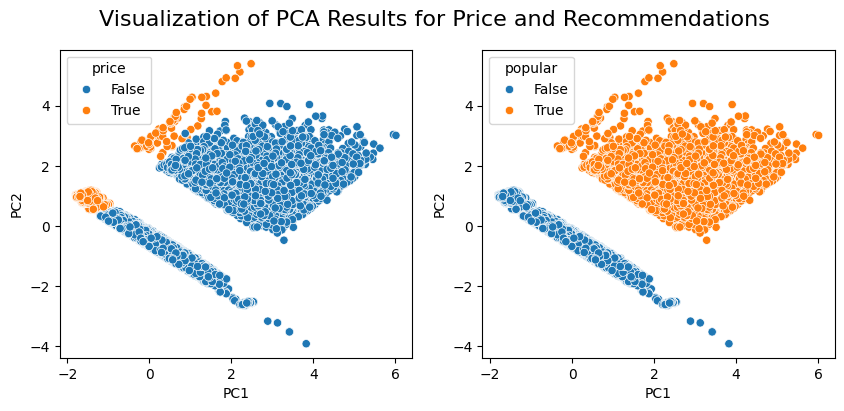

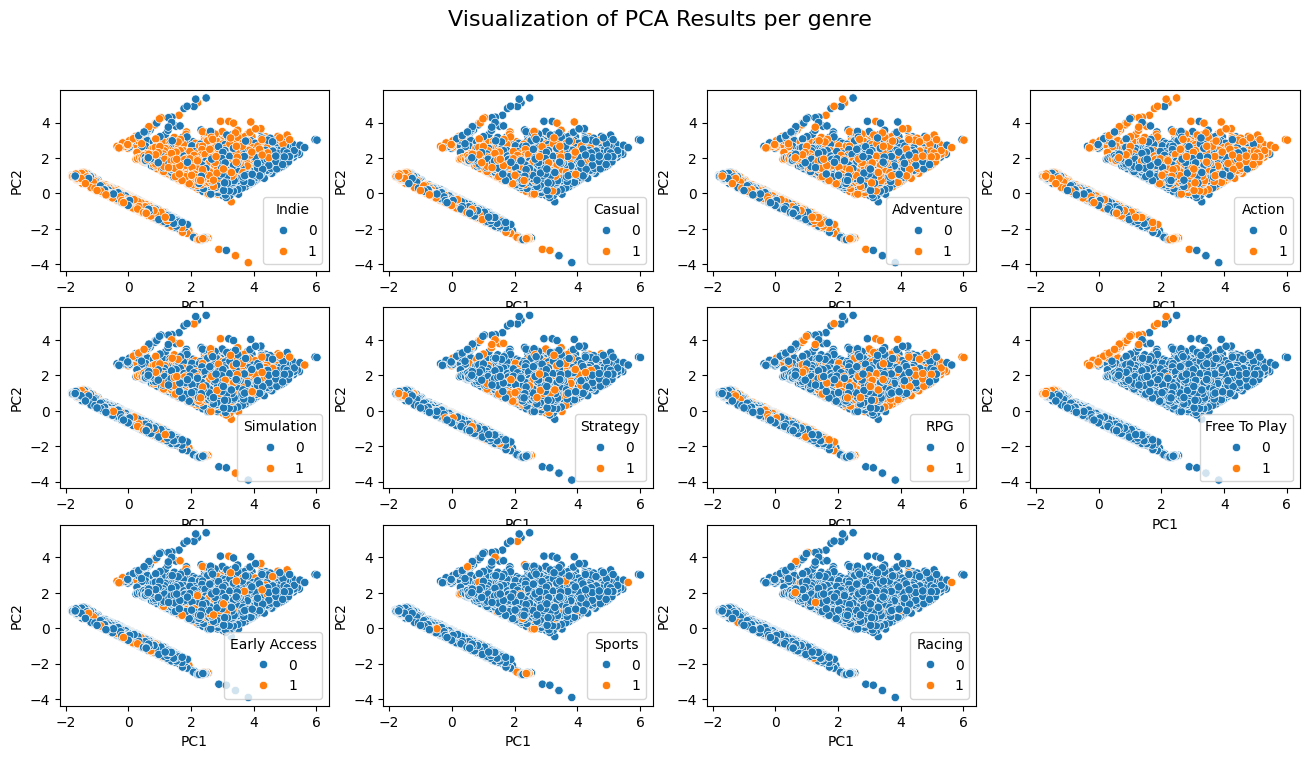

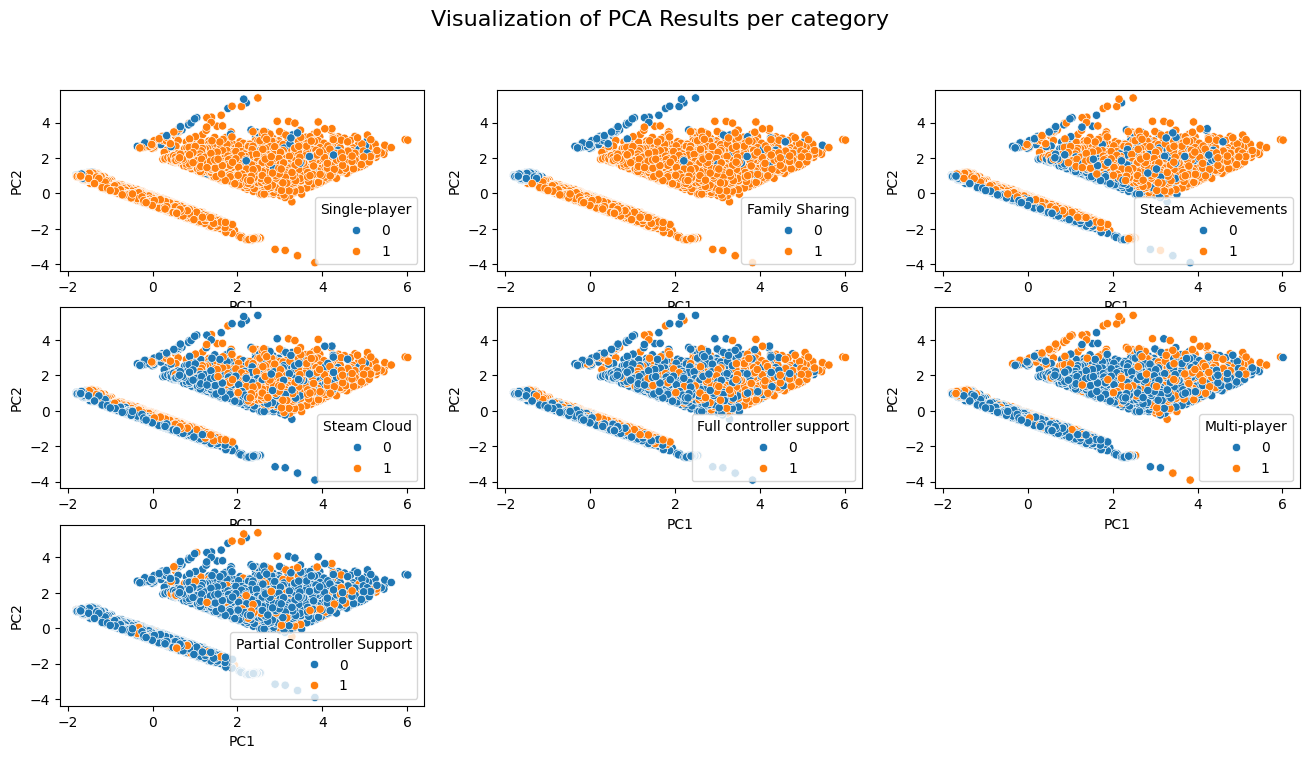

In [6]:
# Use pca for visualization
pca = PCA(n_components=10)
X_pca = pca.fit_transform(featured_data)
pca_df = pd.DataFrame(X_pca[:, :3], columns=["PC1", "PC2", "PC3"])

lineal_columns = pd.DataFrame(validated_data["price"] == 0)
lineal_columns["popular"] = validated_data["recommendations"] > 0

genre_columns = pd.concat(
    [
        featured_data["Indie"].reset_index(drop=True),
        featured_data["Casual"].reset_index(drop=True),
        featured_data["Adventure"].reset_index(drop=True),
        featured_data["Action"].reset_index(drop=True),
        featured_data["Simulation"].reset_index(drop=True),
        featured_data["Strategy"].reset_index(drop=True),
        featured_data["RPG"].reset_index(drop=True),
        featured_data["Free To Play"].reset_index(drop=True),
        featured_data["Early Access"].reset_index(drop=True),
        featured_data["Sports"].reset_index(drop=True),
        featured_data["Racing"].reset_index(drop=True),
    ],
    axis=1,
)

categories_columns = pd.concat(
    [
        featured_data["Single-player"].reset_index(drop=True),
        featured_data["Family Sharing"].reset_index(drop=True),
        featured_data["Steam Achievements"].reset_index(drop=True),
        featured_data["Steam Cloud"].reset_index(drop=True),
        featured_data["Full controller support"].reset_index(drop=True),
        featured_data["Multi-player"].reset_index(drop=True),
        featured_data["Partial Controller Support"].reset_index(drop=True),
    ],
    axis=1,
)

multiple_scatterplot(
    data=pca_df,
    title="Visualization of PCA Results for Price and Recommendations",
    x_col="PC1",
    y_col="PC2",
    n=1,
    m=2,
    hue_values=lineal_columns,
    xsize=10,
    ysize=4,
)
multiple_scatterplot(
    data=pca_df,
    title="Visualization of PCA Results per genre",
    x_col="PC1",
    y_col="PC2",
    n=3,
    m=4,
    hue_values=genre_columns,
    xsize=16,
    ysize=8,
)
multiple_scatterplot(
    data=pca_df,
    title="Visualization of PCA Results per category",
    x_col="PC1",
    y_col="PC2",
    n=3,
    m=3,
    hue_values=categories_columns,
    xsize=16,
    ysize=8,
)

# Test variance on Principal Components

[301298.21875, 232188.625, 190440.78125, 174905.203125, 166901.5, 160932.59375, 156836.46875, 152315.78125, 149531.6875, 146897.5]


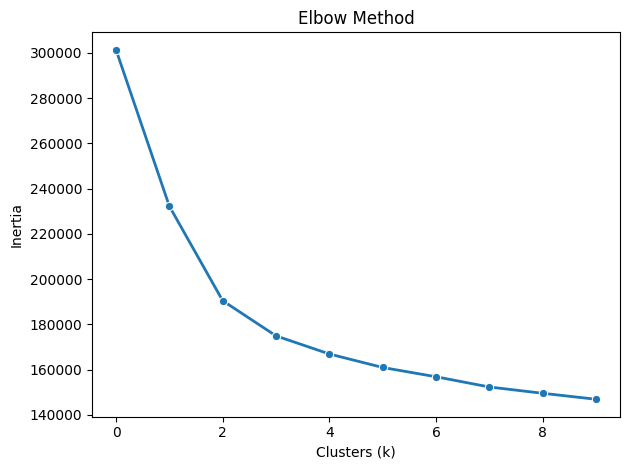

In [ ]:
# Visualice elbow method on inertias
inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(featured_data)
    inertias.append(km.inertia_)

make_plot(
    plot_type="line",
    data=inertias,
    x_col=None,
    y_col=None,
    title='Elbow Method',
    xlabel="Clusters (k)",
    ylabel="Inertia",
    xticks=k_range,
)
plt.show()

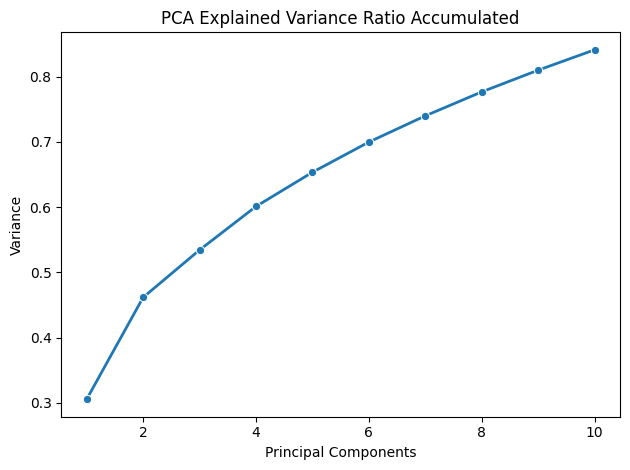

Variance explained by each Principal Component: [0.30536428 0.1561872  0.07275425 0.06677569 0.0524375  0.04633322
 0.0402119  0.03676399 0.03330271 0.03122762]
Total variance explained by PC1+PC2+PC3: 0.53430575


In [ ]:
# Visualice accumulated variance ratio of principal components
make_plot(
    plot_type="line",
    data=None,
    x_col=np.arange(1, 11),
    y_col=pca.explained_variance_ratio_.cumsum(),
    title='PCA Explained Variance Ratio Accumulated',
    xlabel="Principal Components",
    ylabel="Variance",
)
plt.show()

print("Variance explained by each Principal Component:", pca.explained_variance_ratio_)
print(
    "Total variance explained by PC1+PC2+PC3:", pca.explained_variance_ratio_[:3].sum()
)

In [ ]:
# Visualice Silhouette Score
sil_scores = []
for k in range(2, 11):  # empieza en 2, silhouette no aplica a k=1
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(featured_data)
    sil_scores.append(silhouette_score(featured_data, labels))

make_plot(
    plot_type="line",
    data=None,
    x_col=range(2, 11),
    y_col=sil_scores,
    title='Silhouette Score por k',
    xlabel="K",
    ylabel="Silhouette Score",
)
plt.show()

'plt.plot(range(2, 11), sil_scores, marker="o")\nplt.xlabel("k")\nplt.ylabel("Silhouette Score")\nplt.title("Silhouette Score por k")'

In [23]:
# See what features influence more on each principal component
loadings = pd.DataFrame(
    pca.components_.T[:, :3], columns=["PC1", "PC2", "PC3"], index=featured_data.columns
)
loadings["PC1"] = loadings["PC1"].abs()
loadings["PC2"] = loadings["PC2"].abs()
loadings["PC3"] = loadings["PC3"].abs()
loadings

,PC1,PC2,PC3
price,0.703691,0.608356,0.009056
recommendations,0.639234,0.737990,0.031303
Indie,0.025383,0.006560,0.000947
Casual,0.057537,0.008075,0.548018
Adventure,0.039476,0.011887,0.417288
Action,0.008995,0.001864,0.594166
Simulation,0.035970,0.008810,0.248589
Strategy,0.012374,0.005627,0.172983
RPG,0.040560,0.009689,0.102912
Free To Play,0.137601,0.168209,0.055209


# Model Training

In [18]:
# Train a KMEANS model
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(featured_data)
pca_df["labels"] = kmeans_labels
fig = px.scatter_3d(
    pca_df, x="PC1", y="PC2", z="PC3", color="labels", title="PCA 3D Visualization"
)
centroids = pca_df.groupby("labels")[["PC1", "PC2", "PC3"]].mean().reset_index()

# Add centroids
fig.add_trace(
    go.Scatter3d(
        x=centroids["PC1"],
        y=centroids["PC2"],
        z=centroids["PC3"],
        mode="markers+text",
        marker=dict(
            size=12, color="black", symbol="diamond", line=dict(color="white", width=2)
        ),
        text=centroids["labels"],
        textposition="top center",
        name="Centroides",
    )
)
fig.show()